<a href="https://colab.research.google.com/github/faniyonm/Object-Detection-Model-Comparison-YOLO-vs-SSD-on-Pascal-VOC/blob/main/object_detection_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection Model Task

This project examines deep learning approaches for automated object detection by developing a workflow that trains and compares models using standard evaluation metrics using the Pascal VOC dataset. The focus is on understanding how model design and training conditions influence performance. Because typical notebook platforms can impose GPU limits and runtime interruptions, Modal is used as the execution environment to provide stable GPU access and longer runtimes, ensuring reliable training and evaluation.

### Process Overview

* Load and prepare the dataset
* Visualize and inspect the data
* Train a YOLO detection model
* Evaluate YOLO performance metrics
* Train a comparison model SSD
* Evaluate SSD performance metrics
* Compare the results of both models to determine which performs better


In [ ]:
%uv pip install ultralytics
%uv pip install torch torchvision
%uv pip install lxml
%uv pip install matplotlib

Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 16ms
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Audited 2 packages in 17ms
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 4ms
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 7ms
Note: you may need to restart the kernel to use updated packages.


###  1. Loading the Dataset
The Pascal VOC 2012 dataset Iis extracted from a compressed .zip file into a working directory. This allows us to access the images and annotation files required for training the object detection model.


In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/root
['.bashrc', '.ssh', '.wget-hsts', '.profile', '.cache', '.ipython', '.config', 'yolov8n.pt', '.nv', 'runs', 'Pascal VOC 2012.v1-raw.yolov8.zip', 'dataset']


In [ ]:
import zipfile

zip_path = "/root/Pascal VOC 2012.v1-raw.yolov8.zip"
extract_path = "/root/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully.")

Unzipped successfully.


In [ ]:
import os
print(os.listdir("/root/dataset"))

['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'train', 'valid']


In [ ]:
DATASET_PATH = "/root/dataset"

### 2. Visualizing Sample Images
This step verifies that the dataset images and their annotation labels are correctly loaded and aligned. We randomly select a few training images and draw their bounding boxes based on label files. This helps confirm that annotations match the objects in each image before model training begins.


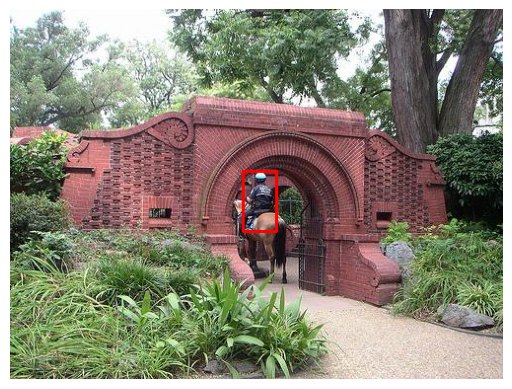

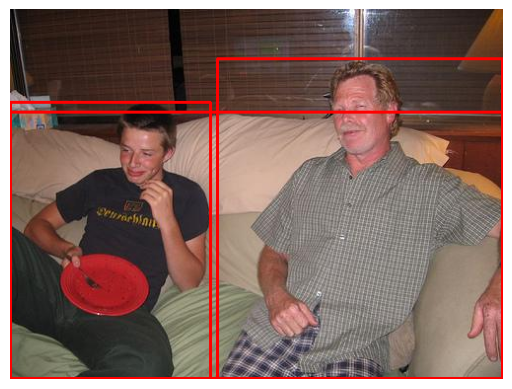

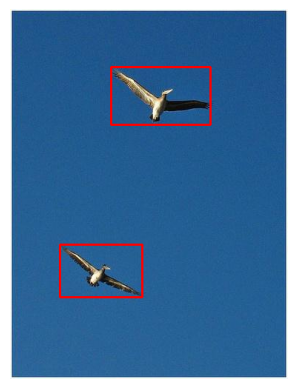

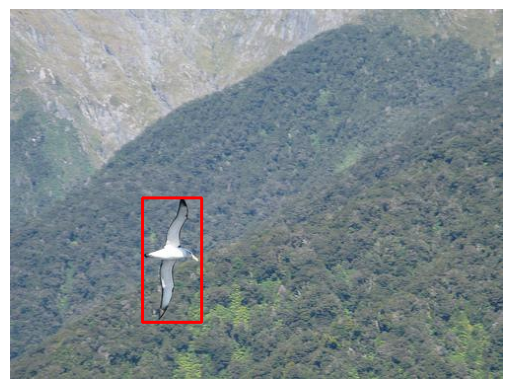

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

DATASET_PATH = "/root/dataset"

img_dir = DATASET_PATH + "/train/images"
label_dir = DATASET_PATH + "/train/labels"

samples = random.sample(os.listdir(img_dir), 4)

for name in samples:

    img = cv2.imread(img_dir + "/" + name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape
    label_file = label_dir + "/" + name.replace(".jpg", ".txt")

    if os.path.exists(label_file):
        with open(label_file) as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

### 3. Train a YOLO Detection Model
A pretrained object detection model is loaded using the Ultralytics YOLO framework. YOLO (You Only Look Once) is a real time object detection architecture that predicts bounding boxes and class probabilities in a single forward pass. Unlike two stage detectors such as Faster R-CNN, YOLO performs detection in one stage, which makes it significantly faster. The line below initializes the YOLOv8 Nano model, which is a lightweight version designed for fast training and inference while still maintaining good detection accuracy.

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

This step starts the training process for the object detection model using the prepared dataset configuration. The training function instructs the model where the dataset is located, how long to train, and which hyperparameters to use.

Training allows the model to learn how to detect objects by adjusting its internal weights based on labeled images. During each epoch, the model processes all training images, compares its predictions with true labels, and updates parameters to reduce prediction error.

In [ ]:
model.train(
    data="/root/dataset/data.yaml",
    project="/root/runs",
    name="pascal_voc_yolov8",
    epochs=5,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.19 🚀 Python-3.12.6 torch-2.8.0+cu129 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pascal_voc_yolov82, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x2b116c345880>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

### 4. Evaluating YOLO Model Performance
After training, the model is evaluated on the validation dataset. This step measures how well the model generalizes to unseen data. The model.val() function computes standard object detection metrics.


In [ ]:
metrics = model.val()

print("\n VALIDATION RESULTS ")

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

print("\nPer-class mAP:")
for i, c in enumerate(metrics.names):
    print(c, ":", metrics.box.maps[i])

Ultralytics 8.4.19 🚀 Python-3.12.6 torch-2.8.0+cu129 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 574.3±307.6 MB/s, size: 42.2 KB)
val: Scanning /root/dataset/valid/labels.cache... 3422 images, 120 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3422/3422 956.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 214/214 8.3it/s 25.7s
                   all       3422       7835      0.695      0.613      0.664      0.487
             aeroplane        134        194      0.851      0.742      0.805      0.592
               bicycle        107        142      0.613      0.507      0.572      0.426
                  bird        146        215      0.812      0.614      0.682      0.488
                  boat        124        205      0.744      0.582      0.654      0.451
                bottle        166        335  

### YOLO Model Evaluation Results
The YOLO model demonstrated strong detection performance on the validation dataset. It achieved a precision of approximately 0.695 and a recall of 0.613, indicating that the model correctly identified most objects while maintaining a relatively low rate of false detections. The mAP at an IoU threshold of 0.5 was 0.664, and the overall mAP across multiple IoU thresholds was 0.487, showing consistent performance across object categories and varying localization strictness levels. Several classes such as bus, train, cat, and dog achieved notably high scores, while smaller or more challenging objects such as bottle and chair showed comparatively lower performance. Overall, the results confirm that the YOLO model provides reliable and well balanced object detection performance on the Pascal VOC dataset.

### 5. SSD Model for Comparison
To provide a meaningful performance comparison, a second object detection model based on the Single Shot Detector architecture is trained and evaluated on the same dataset. SSD is a single stage detection framework that predicts object classes and bounding boxes directly from feature maps without a separate region proposal step. This architecture is known for its efficiency and relatively fast inference speed, making it suitable for real time detection tasks. By training SSD under the same conditions as the first model, the project establishes a fair basis for comparison, allowing differences in accuracy and detection capability to be attributed to model design rather than data or training variations.


In [ ]:
import os
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F

In [ ]:
class SSDDataset(Dataset):
    def __init__(self, img_dir, label_dir):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.images = []

        for img in os.listdir(img_dir):
            label = os.path.join(label_dir, img.replace(".jpg",".txt"))
            if os.path.exists(label) and os.path.getsize(label) > 0:
                self.images.append(img)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir,img_name)
        label_path = os.path.join(self.label_dir,img_name.replace(".jpg",".txt"))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h,w,_ = img.shape

        boxes=[]
        labels=[]

        with open(label_path) as f:
            for line in f:
                cls,x,y,bw,bh = map(float,line.split())

                x1=(x-bw/2)*w
                y1=(y-bh/2)*h
                x2=(x+bw/2)*w
                y2=(y+bh/2)*h

                boxes.append([x1,y1,x2,y2])
                labels.append(int(cls)+1)

        boxes = torch.tensor(boxes,dtype=torch.float32)
        labels = torch.tensor(labels,dtype=torch.int64)

        target = {"boxes":boxes,"labels":labels}
        img = F.to_tensor(img)

        return img,target

In [ ]:
import os
from torch.utils.data import DataLoader

DATASET_PATH = "/root/dataset"

train_dataset = SSDDataset(
    DATASET_PATH + "/train/images",
    DATASET_PATH + "/train/labels"
)

val_dataset = SSDDataset(
    DATASET_PATH + "/valid/images",
    DATASET_PATH + "/valid/labels"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

print("Train images:", len(train_dataset))
print("Valid images:", len(val_dataset))

Train images: 13299
Valid images: 3302


The SSD model is initialized using the torchvision implementation of the SSD300 architecture with a VGG16 backbone. Pretrained weights trained on a large scale dataset are first loaded to provide the model with strong initial feature representations. Since the pretrained model is configured for a different number of classes, the classification head is replaced with a new one designed for 21 classes, which corresponds to the Pascal VOC dataset classes plus a background class. The input channel sizes for each detection layer are extracted from the original head so that the replacement layer matches the architecture correctly. The model is then transferred to the available computation device, allowing it to utilize GPU acceleration when available. This setup ensures that the model is properly configured for training on the target dataset while benefiting from transfer learning.

In [ ]:
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection import SSD300_VGG16_Weights

num_classes = 21  # VOC: 20 classes + background

# Loading pretrained COCO weights
weights = SSD300_VGG16_Weights.DEFAULT

model = ssd300_vgg16(weights=weights)

# Now rebuilding head for 21 classes
# Correctly extracting the list of in_channels from all modules in the existing classification head
in_channels = [m.in_channels for m in model.head.classification_head.module_list]
num_anchors = model.anchor_generator.num_anchors_per_location()

from torchvision.models.detection.ssd import SSDClassificationHead

model.head.classification_head = SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("SSD correctly initialized for 21 classes.")

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|███████████████████████████████████████████████████████████████████████| 136M/136M [00:01<00:00, 74.8MB/s]


SSD correctly initialized for 21 classes.


### SSD Training
The SSD model is trained using stochastic gradient descent optimization with a small learning rate, momentum, and weight decay to promote stable convergence and prevent overfitting.

In [ ]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.0005,
    momentum=0.9,
    weight_decay=0.0005
)

During each training epoch, batches of images and corresponding target annotations are transferred to the computation device and passed through the model to compute detection losses. These losses, which represent classification and localization errors, are summed to obtain a total loss value. Before updating parameters, the code checks for invalid numerical values to ensure training stability. The optimizer then performs backpropagation and updates the model weights. After each epoch, the average loss across all training batches is reported, allowing monitoring of learning progress and convergence behavior.

In [ ]:
for epoch in range(5):

    model.train()
    total_loss = 0

    for imgs, targets in train_loader:

        imgs = [img.to(device) for img in imgs]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(l for l in loss_dict.values())

        if torch.isnan(loss) or torch.isinf(loss):
            continue

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss/len(train_loader))

Epoch: 0 Loss: 4.45544773071413
Epoch: 1 Loss: 3.059206913625771
Epoch: 2 Loss: 2.6243688549109416
Epoch: 3 Loss: 2.295018747816298
Epoch: 4 Loss: 2.0227371914087113


In [ ]:
import sys
!{sys.executable} -m pip install pycocotools


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import importlib
import sys

# remove cached torchmetrics modules
modules_to_remove = [m for m in sys.modules if "torchmetrics" in m]
for m in modules_to_remove:
    del sys.modules[m]

# now reimport
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric = MeanAveragePrecision()
print("Metric initialized successfully")

Metric initialized successfully


### 6. Evaluating SSD Model
The evaluation phase begins by resetting the metric object to ensure that previous results do not influence the current computation. The model is switched to evaluation mode to disable training specific operations such as gradient updates. Using a no gradient context improves efficiency and reduces memory usage during validation. Each batch of validation images is passed through the model to generate predicted bounding boxes and class scores. Predictions and corresponding ground truth targets are moved to the central processing unit and supplied to the evaluation metric. After processing all validation batches, the metric computes aggregate performance measures, including mean average precision at different intersection over union thresholds and recall. These results provide a quantitative assessment of the model’s detection accuracy and overall generalization performance.


In [ ]:
metric.reset()

model.eval()

with torch.no_grad():
    for imgs, targets in val_loader:

        imgs = [img.to(device) for img in imgs]
        preds = model(imgs)

        preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets = [{k: v.cpu() for k, v in t.items()} for t in targets]

        metric.update(preds, targets)

results = metric.compute()

print("\n SSD Evaluation Results ")
print("mAP:", results["map"].item())
print("mAP50:", results["map_50"].item())
print("Recall:", results["mar_100"].item())

/usr/local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)



 SSD Evaluation Results 
mAP: 0.3789134919643402
mAP50: 0.6233192682266235
Recall: 0.5241432189941406


### SSD Model Evaluation Results
The SSD model achieved a mean average precision of approximately 0.379, an mAP at 0.5 intersection over union of 0.623, and a recall of about 0.524. These values indicate that the model is capable of detecting a substantial proportion of objects and localizing them reasonably well at moderate overlap thresholds. However, the lower overall mAP suggests that detection consistency across stricter thresholds and across classes is more limited. The recall score shows that the model successfully identifies many objects but still misses a noticeable portion. Overall, the results demonstrate that while SSD provides functional detection performance, its accuracy is moderate and leaves room for improvement compared to more advanced detection architectures.

### 7. Comparison of the TWO Models
When comparing both models, the YOLO architecture clearly outperformed the SSD model across all key evaluation metrics. YOLO achieved higher precision, higher recall, and a substantially higher overall mean average precision, indicating more accurate detections and fewer missed objects. Although SSD produced a reasonably competitive mAP at the lower intersection over union threshold, its performance declined at stricter thresholds, which suggests weaker localization precision. In contrast, YOLO maintained stronger performance consistency across thresholds and object categories. In addition, SSD required a longer training time to reach convergence, which further highlights the efficiency advantage of YOLO. These results indicate that YOLO provides more robust, reliable, and computationally efficient detection capability on the dataset, while SSD serves as a useful baseline model but does not match the accuracy or training efficiency of the more advanced architecture.